Data Preprocessing for K-Means

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

Load the Feature Dataset

In [2]:
customer_features = pd.read_csv("../datasets/cleaned/customer_features.csv")

customer_features.head()

,customer_unique_id,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,12.00,129.90,1,8.0,credit_card
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,8.29,18.90,1,1.0,credit_card
2,0000f46a3911fa3c0805444483337064,537,1,86.22,17.22,69.00,1,8.0,credit_card
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,17.63,25.99,1,4.0,credit_card
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,16.89,180.00,1,6.0,credit_card


Dataset Overview

In [4]:
customer_features.shape

(93335, 9)

In [5]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93335 entries, 0 to 93334
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_unique_id     93335 non-null  object 
 1   Recency                93335 non-null  int64  
 2   Frequency              93335 non-null  int64  
 3   Monetary               93335 non-null  float64
 4   Total_Freight          93335 non-null  float64
 5   Average_Product_Price  93335 non-null  float64
 6   Total_Products         93335 non-null  int64  
 7   Average_Installments   93335 non-null  float64
 8   Preferred_Payment      93335 non-null  object 
dtypes: float64(4), int64(3), object(2)
memory usage: 6.4+ MB


In [6]:
customer_features.describe()

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments
count,93335.000000,93335.000000,93335.000000,93335.000000,93335.000000,93335.000000,93335.000000
mean,237.898752,1.033417,211.844495,24.639861,125.831300,1.232239,2.900600
std,152.545822,0.209099,642.239857,27.057386,190.553959,0.819845,2.677201
min,1.000000,1.000000,9.590000,0.000000,0.850000,1.000000,0.000000
25%,114.000000,1.000000,63.750000,14.100000,42.900000,1.000000,1.000000
50%,219.000000,1.000000,112.950000,17.680000,79.000000,1.000000,2.000000
75%,346.000000,1.000000,201.740000,26.550000,139.900000,1.000000,4.000000
max,695.000000,15.000000,109312.640000,1794.960000,6735.000000,75.000000,24.000000


In [7]:
customer_features.isnull().sum()

customer_unique_id       0
Recency                  0
Frequency                0
Monetary                 0
Total_Freight            0
Average_Product_Price    0
Total_Products           0
Average_Installments     0
Preferred_Payment        0
dtype: int64

In [8]:
customer_features.duplicated().sum()

np.int64(0)

Check Feature Distributions

Recency

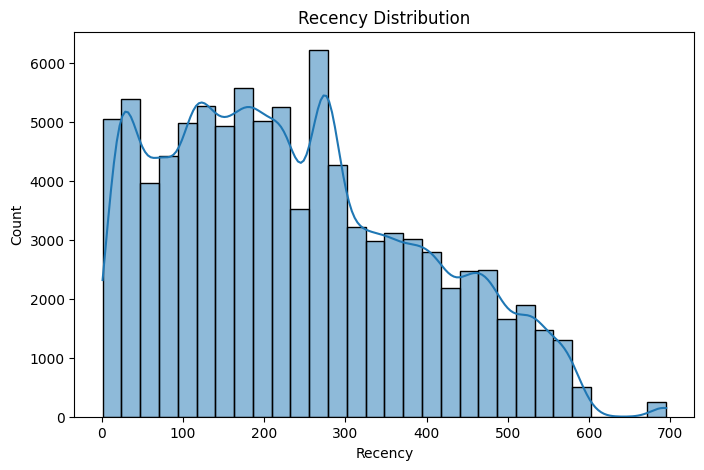

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Recency"], bins=30, kde=True)

plt.title("Recency Distribution")
plt.show()

Frequency

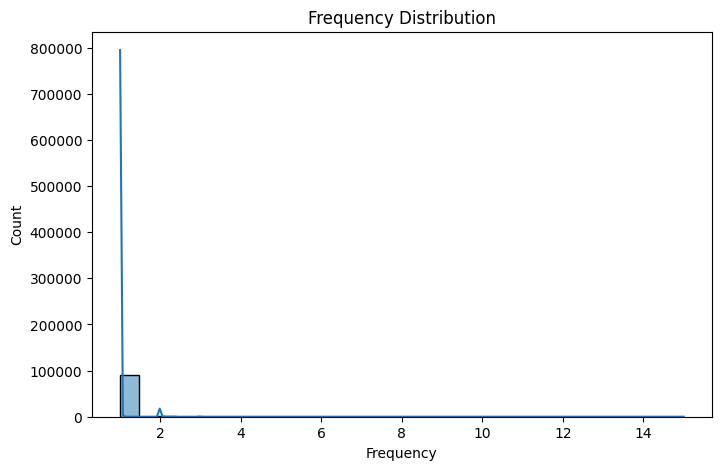

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Frequency"], bins=30, kde=True)

plt.title("Frequency Distribution")
plt.show()

Monetary

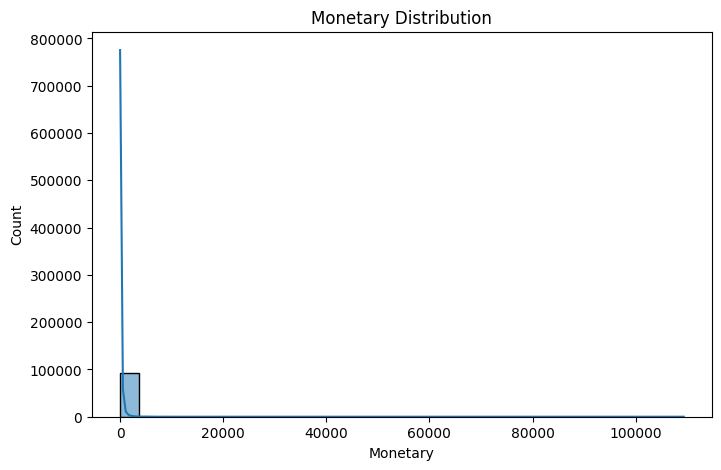

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Monetary"], bins=30, kde=True)

plt.title("Monetary Distribution")
plt.show()

Total Freight

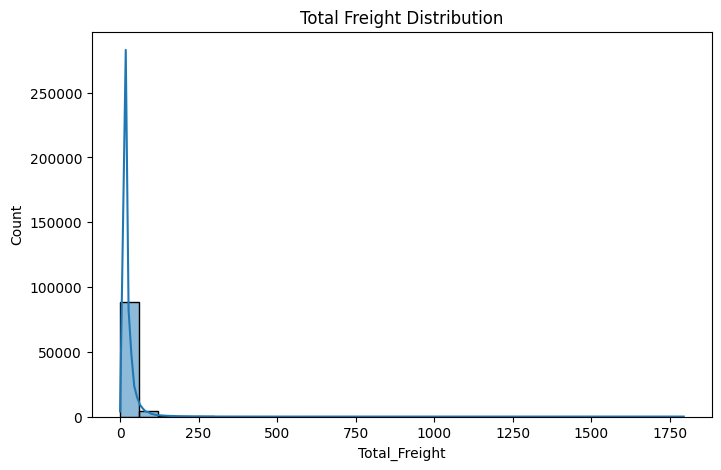

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Total_Freight"], bins=30, kde=True)

plt.title("Total Freight Distribution")
plt.show()

Average Product Price

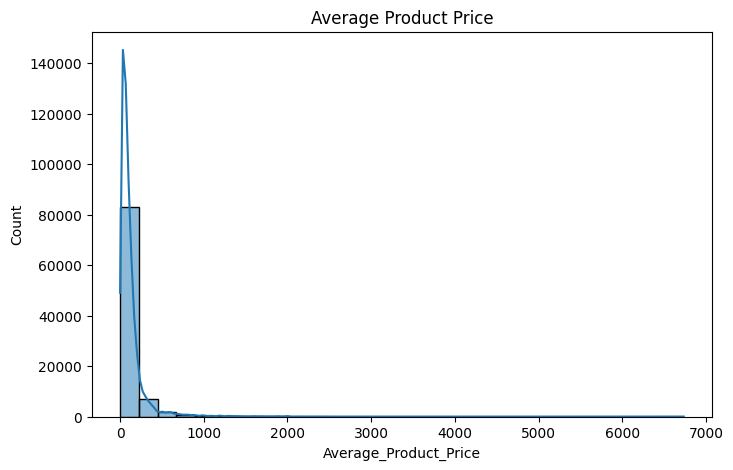

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Average_Product_Price"], bins=30, kde=True)

plt.title("Average Product Price")
plt.show()

Total Products

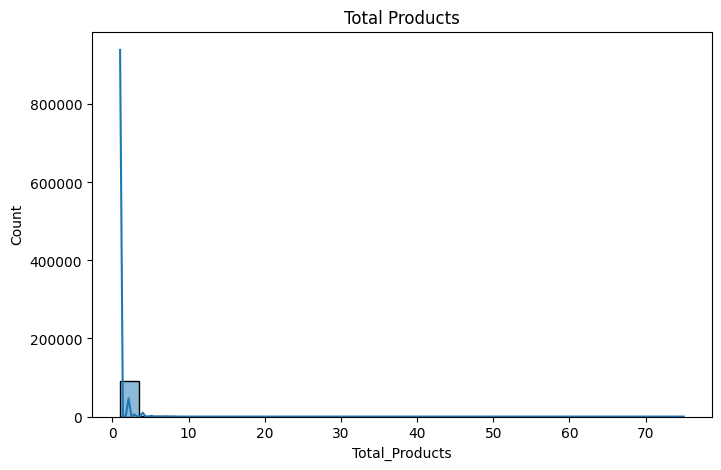

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(customer_features["Total_Products"], bins=30, kde=True)

plt.title("Total Products")
plt.show()

Outlier Detection

Recency

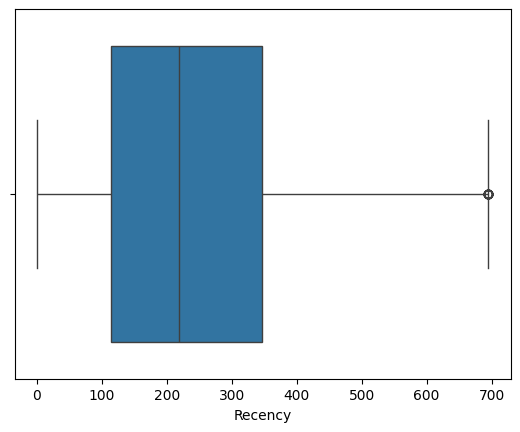

In [15]:
sns.boxplot(
    x=customer_features["Recency"]
)

plt.show()

Frequency

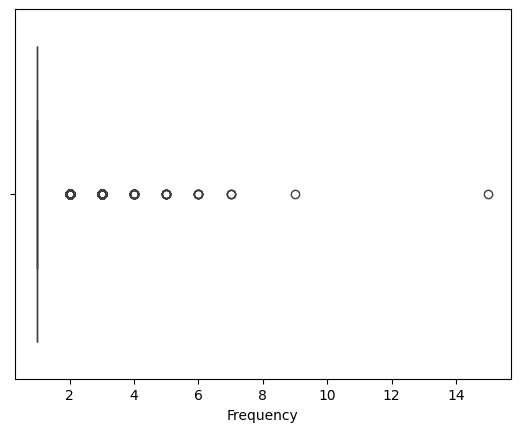

In [16]:
sns.boxplot(
    x=customer_features["Frequency"]
)

plt.show()

Monetary

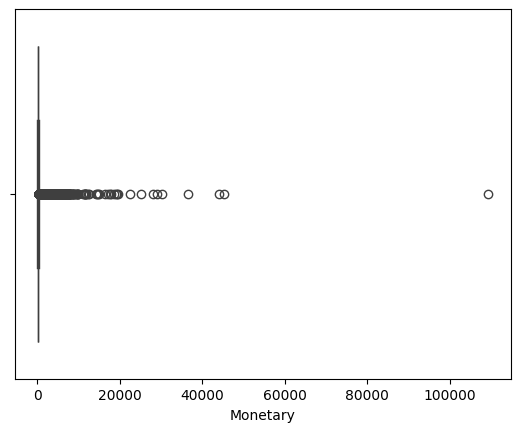

In [17]:
sns.boxplot(
    x=customer_features["Monetary"]
)

plt.show()

Encode the Payment Method

In [18]:
customer_features = pd.get_dummies(
    customer_features,
    columns=["Preferred_Payment"],
    drop_first=True
)

customer_features.head()

,customer_unique_id,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,12.00,129.90,1,8.0,True,False,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,8.29,18.90,1,1.0,True,False,False
2,0000f46a3911fa3c0805444483337064,537,1,86.22,17.22,69.00,1,8.0,True,False,False
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,17.63,25.99,1,4.0,True,False,False
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,16.89,180.00,1,6.0,True,False,False



Select Features

In [19]:
X = customer_features.drop(
    columns=["customer_unique_id"]
)

X.head()

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
0,112,1,141.90,12.00,129.90,1,8.0,True,False,False
1,115,1,27.19,8.29,18.90,1,1.0,True,False,False
2,537,1,86.22,17.22,69.00,1,8.0,True,False,False
3,321,1,43.62,17.63,25.99,1,4.0,True,False,False
4,288,1,196.89,16.89,180.00,1,6.0,True,False,False


Feature Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Convert Back to DataFrame

In [21]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
0,-0.825322,-0.159817,-0.108908,-0.467153,0.021352,-0.283273,1.904761,0.552748,-0.124605,-0.13807
1,-0.805656,-0.159817,-0.287518,-0.604269,-0.561163,-0.283273,-0.709924,0.552748,-0.124605,-0.13807
2,1.960741,-0.159817,-0.195605,-0.274228,-0.298244,-0.283273,1.904761,0.552748,-0.124605,-0.13807
3,0.544765,-0.159817,-0.261935,-0.259075,-0.523956,-0.283273,0.410655,0.552748,-0.124605,-0.13807
4,0.328436,-0.159817,-0.023285,-0.286425,0.284271,-0.283273,1.157708,0.552748,-0.124605,-0.13807


Verify Scaling

In [22]:
X_scaled.describe().round(2)

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
count,93335.00,93335.00,93335.00,93335.00,93335.00,93335.00,93335.00,93335.00,93335.00,93335.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.55,-0.16,-0.31,-0.91,-0.66,-0.28,-1.08,-1.81,-0.12,-0.14
25%,-0.81,-0.16,-0.23,-0.39,-0.44,-0.28,-0.71,0.55,-0.12,-0.14
50%,-0.12,-0.16,-0.15,-0.26,-0.25,-0.28,-0.34,0.55,-0.12,-0.14
75%,0.71,-0.16,-0.02,0.07,0.07,-0.28,0.41,0.55,-0.12,-0.14
max,3.00,66.79,169.88,65.43,34.68,89.98,7.88,0.55,8.03,7.24


Correlation Matrix

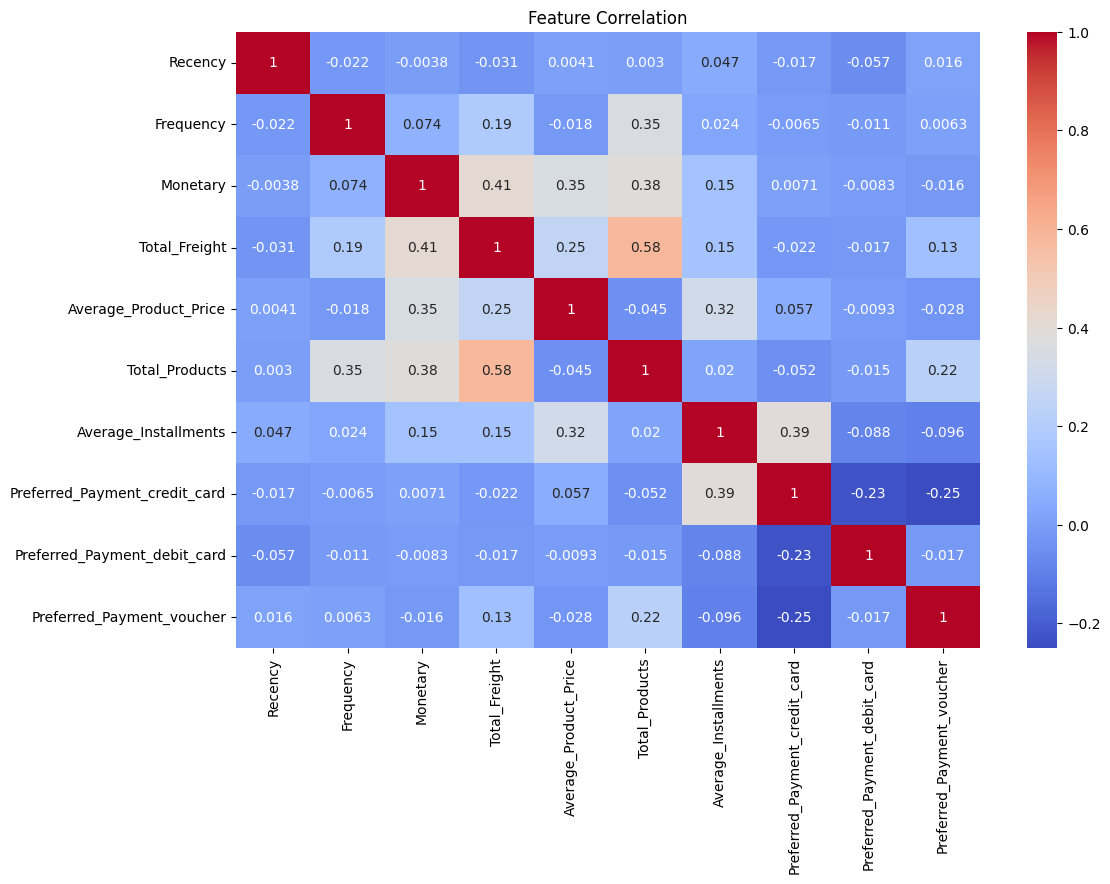

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X_scaled.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

Save the Processed Dataset

In [24]:
X_scaled.to_csv(
    "../datasets/cleaned/customer_features_scaled.csv",
    index=False
)

print("Scaled dataset saved successfully!")

Scaled dataset saved successfully!


In [25]:
import joblib

joblib.dump(
    scaler,
    "../datasets/cleaned/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
